In [1]:
# solver for Yukawa potential
# central field potential - use radial schrodinger eqn

In [2]:
# ========================
# Import Packages/Modules
# ========================
import matplotlib.pyplot as plt           # from hydrogen.py
import numpy as np                        # from hydrogen.py
#import vpython as vp
#vec = vp.vector
from math import *                        # for exponential
#from scipy.constants import e, hbar, m_p  # for numerical values of q_e, hbar, m_p
from jwanglibs import rootfinder as rtf   # from hydrogen.py
from scipy.constants import m_p, m_n

In [3]:
# =================================
# Conversions to MeV/Natural Units
# =================================
# Proton Mass
mP = m_p  # kg
mP = mP*1e30  # change order scale
mP = mP/1.783  # MeV/c^2, but c = 1 in natural units
print('mP = %.5f MeV' %mP)  # MeV

# Neutron Mass
mN = m_n  # kg
mN = mN*1e30  # change order scale
mN = mN/1.783  # MeV/c^2, but c = 1 in natural units
print('mN = %.5f MeV' %mN)  # MeV

# ===================
# Initial Conditions
# ===================
xL, xR, N = 10e-6, 120., 2200     # limits, interval
hbar, V0 = 1.0, 1.0      # constants
m = 1.0
a = 1.0                           # radius of potential well [L]^1 (fm)
lamda = 0.0                       # yukawa interaction range [L]^-1 (fm^-1)
h = (xR-xL)/N                     # step size
Lmax, EL = 4, []                  # define max L, blank L array
M = N // 2                        # M = matching point
print('a = %.1f fm' %a)  # fm

mP = 938.09418 MeV
mN = 939.38727 MeV
a = 1.0 fm


In [46]:
#For now, we will be using 1.0 for our constants for easy calculation and visualization.

In [36]:
# ========================
# Define Yukawa Potential
# ========================
def V(r):
    '''
    if r <= a:
        return -V0                     # potential well inside nuclear radius
    else:
        return -V0*np.exp(-lamda*r)/r  # exponential decay outside well
    '''
    return np.where(r <= a, -V0, -V0*np.exp(-lamda*r)/r)

In [37]:
# =============================
# Define Centrifugal Potential
# =============================
def centrifugal(r):
    return hbar**2*L*(L+1)/(2*m*r**2)

In [38]:
# ===========================
# Define Effective Potential
# ===========================
def V_eff(r):                                                  # effective potential
    '''
    from hydrogen.py
    return L*(L+1)/(2*m*r**2) - 1/(4*pi*)/r                    # centrifugal + coulomb
    '''
    return np.where(r <= a, V(r), centrifugal(r) + V(r))  # centrifugal + yukawa

In [39]:
# ========================
# Define Numerov Schr Eqn
# ========================
def f(r):                            # Sch eqn in Numerov form
    return 2*m*(E-V_eff(r))/hbar**2  #rearrange radial Sch eqn

In [40]:
# ====================
# Define Numerov func
# ====================
def numerov(f, u, n, x, h):     # Numerov integrator for $u''+f(x)u=0$
    nodes, c = 0, h**2/12.       # given $[u_0,u_1]$, return $[u_0,u_1,...,u_{n+1}]$
    f0, f1 = 0., f(x+h)
    for i in range(n):
        x += h
        f2 = f(x+h)             # Numerov method below, 
        u.append((2*(1-5*c*f1)*u[i+1] - (1+c*f0)*u[i])/(1+c*f2))
        f0, f1 = f1, f2
        if u[-1]*u[-2] < 0.0:
            nodes += 1
    return u, nodes             # return u, nodes

In [41]:
# ==================
# Define shoot func
# ==================
def shoot(En):
    global E                    # E needed in f(r)
    E, c, xm = En, (h**2)/6., xL + M*h
    wfup, nup = numerov(f, [0,.1], M, xL, h)
    wfdn, ndn = numerov(f, [0,.1], N-M, xR, -h)     # $f'$ from 
    dup = ((1+c*f(xm+h))*wfup[-1] - (1+c*f(xm-h))*wfup[-3])/(h+h)
    ddn = ((1+c*f(xm+h))*wfdn[-3] - (1+c*f(xm-h))*wfdn[-1])/(h+h)
    return dup*wfdn[-2] - wfup[-2]*ddn

In [47]:
# ===================
# Initial Conditions
# ===================
xL, xR, N = 10e-6, 120., 2200    # limits, interval
hbar, V0 = 1.0, 10.0               # constants
m = 1.0
#m = mP                            # mass of proton
a = 1.0                       # radius of potential well [L]^1 (fm)
lamda = 0.2                       # yukawa interaction range [L]^-1 (fm^-1)
h = (xR-xL)/N                     # step size
Lmax, EL = 8, []                  # define max L, blank L array
M = N // 2                        # M = matching point

In [ ]:
# ================================================
# Calculate energy for n, l, and associated nodes
# ================================================
Estart, dE = -.5/np.arange(1, Lmax+1)**2-.1, 0.001      # $\sum_n -1/2n^2$
for L in range(Lmax):
    n, E1, Ea = L+1, Estart[L], []
    #u0, u1 = 0.0, (xL+h)**(L+1)
    while (E1 < -4*dE):             # sweep E range for each L (does this condition get changed?)
        E1 += dE
        if (shoot(E1)*shoot(E1 + dE) > 0):
            continue
        E = rtf.bisect(shoot, E1, E1 + dE, 1.e-8)
        Ea.append(E)
        wfup, nup = numerov(f, [0,.1], M-1, xL, h)      # calc wf
        wfdn, ndn = numerov(f, [0,.1], N-M-1, xR, -h)
        psix = np.concatenate((wfup[:-1], wfdn[::-1]))
        psix[M:] *= wfup[-1]/wfdn[-1]                   # match
        print ('nodes = %i, n = %i,l = %i, E = %.8e' %(nup+ndn, n, L, E))
        n += 1
    EL.append(Ea)

nodes = 3, n = 1,l = 0, E = -5.48211236e-01
nodes = 5, n = 2,l = 0, E = -1.75010665e-01
nodes = 5, n = 3,l = 0, E = -2.91538369e-02
nodes = 4, n = 2,l = 1, E = -1.37372320e-01
nodes = 5, n = 3,l = 1, E = -1.56450023e-02
nodes = 5, n = 3,l = 2, E = -7.21453337e-02
nodes = 4, n = 4,l = 3, E = -3.31151075e-03
nodes = 3, n = 5,l = 4, E = -1.14478349e-01
nodes = 2, n = 6,l = 5, E = -5.05631067e-02


<>:8: SyntaxWarning: invalid escape sequence '\e'
<>:8: SyntaxWarning: invalid escape sequence '\e'
/var/folders/0g/j1m3j1kj205g8kh8b2z5kdcm0000gn/T/ipykernel_40908/1184856735.py:8: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$'), plt.ylabel('$E$')


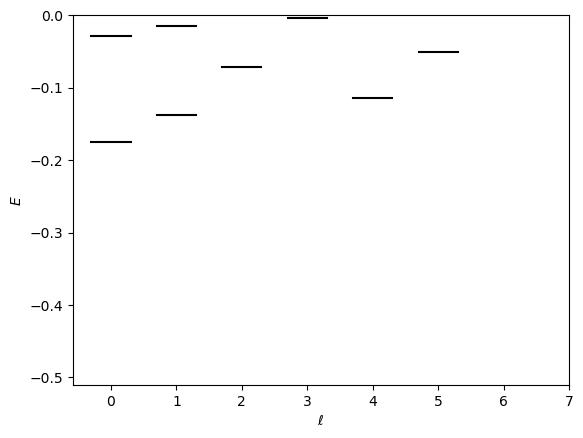

In [49]:
# =========
# Plotting
# =========
plt.figure()                        # plot energy levels
for L in range(Lmax):
    for i in range(len(EL[L])):
        plt.plot([L-.3, L+.3], [EL[L][i]]*2, 'k-')
    plt.xlabel('$\ell$'), plt.ylabel('$E$')
    plt.ylim(-0.51, 0.0), plt.xticks(range(Lmax))
plt.show()

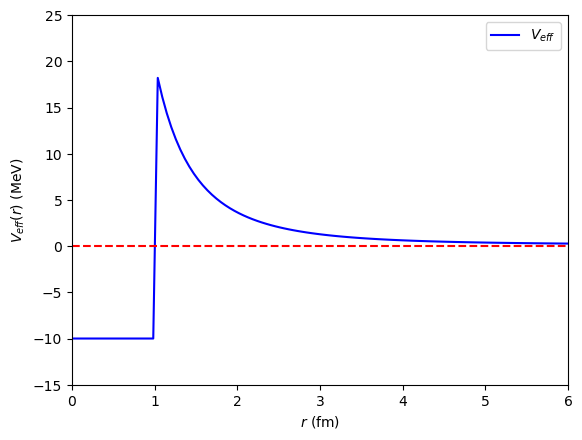

In [65]:
r = np.linspace(xL, xR, N)

plt.figure()
plt.plot(r, V_eff(r), 'b-', label='$V_{eff}$')
#plt.plot(r, V(r), 'g-', label='$V(r)$')
#plt.plot(r, centrifugal(r), 'm-', label='Centrifugal')
plt.axhline(0, color='r', linestyle='--')
plt.xlim(0, 6)
plt.ylim(-15, 25)
plt.xlabel('$r$ (fm)')
plt.ylabel('$V_{eff}(r)$ (MeV)')
plt.legend()
plt.show()